# Model Training and Evaluation Pipeline: Geo-conditioned U-Net Mixture-of-Experts(GUM)

## Overview
This document details the training and evaluation workflow for the GUM. The pipeline covers feature assembly, stratified data splitting, normalization, model training, and comprehensive performance evaluation across different sky conditions and times of day.

---

## 1. Data Assembly and Feature Engineering
The initial phase combines satellite band data with geographic elevation features to create the final input tensors for the model. 

* **Input Sources:** * Satellite Bands: `bands_day_paired_no_twillight.npz` (10 selected channels)
  * Elevation Data: `hk_geom_50x50.npz`
* **Output Tensor Configuration:**
  * **X (Features):** Shape `(67638, 12, 50, 50)`
  * **y (Target CSI):** Shape `(67638, 1, 50, 50)`

## 2. Stratified Data Splitting
To ensure robust model evaluation, the dataset is split chronologically while stratifying across clear and cloudy sky conditions (using thresholds: `clear_thr=0.8`, `cloudy_thr=0.35`).

* **Training Set:** 80% (54,101 samples) | Mean Target: 0.6992
* **Validation Set:** 10% (6,783 samples) | Mean Target: 0.6975
* **Test Set:** 10% (6,754 samples) | Mean Target: 0.6985

> **Note:** Channel minimum and maximum values for normalization (`channel_min`, `channel_max`) are calculated **strictly on the Training Set** to prevent data leakage, then applied across all datasets via the `BandsCamsDataset` class using a batch size of 64.

---

## 3. Model Architecture and Training
The model utilizes a spatial gating mechanism to blend predictions from multiple experts.

* **Model Architecture:** `GUM` (Gated Unified Model)
  * **Feature Size:** 64
  * **Experts (K):** 2
  * **Gate Temperature:** 0.5
* **Training Hyperparameters:**
  * **Epochs:** 50
  * **Learning Rate:** `1e-4` (Max `3e-4`)
  * **Weight Decay:** `1e-3`
  * **Checkpoint:** `best_gum.pt`

---

## 4. Evaluation and Performance Metrics
The best model checkpoint is evaluated on the Test Set. Performance is measured using Clear Sky Index (CSI) and Global Horizontal Irradiance (GHI) across varying temporal and meteorological categories.

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import os
from pathlib import Path
from torch.utils.data import DataLoader
import torch 
from nocitis.gum.utils import (
    stratified_split_grouped_by_time,
    make_labels,
    summarize_split_csi_mean
)
from nocitis.gum.bands_and_cams import(
    load_bands_and_cams,
)
from nocitis.gum.dataset import(
    BandsCamsDataset,
)
from nocitis.gum.train import(
    train_gum,gate_stats,)

from nocitis.gum.evaluate import(
    evaluate_table_metrics
)
from nocitis.gum.data_preprocessing import(
    build_band_tensor_with_elevation,
)
from nocitis.gum.plot import(
    plot_full_images_from_loader,
)
from nocitis.gum.model import GUM

In [2]:
ROOT_DIR = Path.cwd()
while not (ROOT_DIR / "data").exists() and ROOT_DIR != ROOT_DIR.parent:
    ROOT_DIR = ROOT_DIR.parent

# Change working directory to NOCITIS/ root
os.chdir(ROOT_DIR)
print("Updated Working Directory:", os.getcwd())

Updated Working Directory: /Users/tjdu/Desktop/NOCITIS


## 1. Data Assembly and Feature Engineering

In [4]:
bands_npz_name = "data/bands/modeldata/bands_day_paired_no_twillight.npz"
elevation_npz_name = "data/elevation/hk_geom_50x50.npz"
bands_used = [
    'tbb_08','tbb_09','tbb_10','tbb_11','tbb_12',
    'tbb_13','tbb_14','tbb_15','tbb_16','SAZ'
]

In [ ]:
shape, out = build_band_tensor_with_elevation(
    bands_npz_name=bands_npz_name,
    elevation_npz_name=elevation_npz_name,
    bands_used=bands_used,
    output_path="../Data/output/bands_day_pairs_with_elevation.npz",
)
print("Saved:", out)
print("Final shape:", shape)

In [3]:
X, y = load_bands_and_cams(
    bands_npz_path="data/gum/training/bands_day_pairs_with_elevation.npz", # X: LWIR bands + GEO
    cams_npz_path="data/gum/training/cams_day_paired_no_twillight.npz", # y: target y
    bands_indices_used=None,  
    eps=1e-6,
    verbose=True,
)

X shape: (67638, 12, 50, 50)
y shape: (67638, 1, 50, 50)
X finite: True
y finite: True
X stats: min 0.0 max 804.1715698242188
y stats: min 0.048625361174345016 max 1.0


## 2. Stratified Data Splitting

In [4]:
import pandas as pd
import numpy as np

# --- 1. Load Data ---
temp_df = pd.read_csv("data/temperature/hk_average_temperature.csv")
temp_df['dt'] = pd.to_datetime(temp_df['Date time'].astype(str), format='%Y%m%d%H%M')
temp_df = temp_df.set_index('dt').sort_index()

# --- 2. HEAL RAW NaNs ---
temp_df['AverageTemperature'] = temp_df['AverageTemperature'].interpolate(method='time', limit_direction='both')

# Convert HKT to UTC
temp_df = temp_df.tz_localize('Asia/Hong_Kong').tz_convert('UTC')

# --- 3. Align to 15-minute intervals ---
temp_15_utc_k = temp_df['AverageTemperature'].resample('15min').interpolate(method='linear') + 273.15

# --- 4. Parse CAMS time 't' ---
cams = np.load("data/gum/training/cams_day_paired_no_twillight.npz")
t = cams["time_min"]
t_dt = pd.to_datetime(t, unit='m', utc=True)

# --- 5. Strict Order-Preserving Alignment ---
X_surface_k = temp_15_utc_k.reindex(t_dt, method='nearest').values

if np.isnan(X_surface_k).any():
    nan_count = np.isnan(X_surface_k).sum()
    print(f"Warning: Filled {nan_count} out-of-bounds samples with global mean.")
    X_surface_k = pd.Series(X_surface_k).fillna(np.nanmean(X_surface_k)).values

# --- 6. Apply Normalization (MacBook Air M1 Optimized) ---
T_surf_broadcast = X_surface_k[:, np.newaxis, np.newaxis, np.newaxis]

# [SAFETY GUARD] Prevent Jupyter double-execution bug
if np.nanmax(X[:, :9, :, :]) < 5.0:
    print("⚠️ SKIPPED: Data is already normalized!")
    print("If you need to run this again, re-run the cell above that loads 'X' first.")
else:
    # Ensure float32 to prevent 64-bit casting (saves ~4GB RAM on M1)
    if X.dtype != np.float32:
        X = X.astype(np.float32)

    # Process in batches to prevent M1 Swap Memory lockups
    batch_size = 128  

    for i in range(0, X.shape[0], batch_size):
        # Create a VIEW (Zero memory cost)
        batch_X = X[i : i + batch_size, :9, :, :]
        batch_T = T_surf_broadcast[i : i + batch_size]
        
        # In-place division: batch_X = batch_X / batch_T
        np.divide(batch_X, batch_T, out=batch_X)
        
        # In-place power: batch_X = batch_X ** 4
        np.power(batch_X, 4, out=batch_X)

    print("Normalization complete! All CSV NaNs were healed before alignment.")
    print(f"Final check: Number of NaNs in X (first 9 channels): {np.isnan(X[:, :9, :, :]).sum()}")

Normalization complete! All CSV NaNs were healed before alignment.
Final check: Number of NaNs in X (first 9 channels): 0


In [5]:
import numpy as np

def qc_check_X(X_tensor):
    print("=== QC Report for Feature Tensor X ===\n")
    
    # 1. Shape and Data Type
    print("--- 1. Basic Properties ---")
    print(f"Shape: {X_tensor.shape}")
    print(f"Data Type: {X_tensor.dtype}")
    
    # 2. Mathematical Integrity (NaNs and Infs)
    print("\n--- 2. Mathematical Integrity ---")
    nan_count = np.isnan(X_tensor).sum()
    inf_count = np.isinf(X_tensor).sum()
    
    print(f"Total NaNs: {nan_count}")
    print(f"Total Infs: {inf_count}")
    
    if nan_count == 0 and inf_count == 0:
        print("✅ PASS: X is completely clean of NaNs and infinite values.")
    else:
        print("❌ FAIL: X contains invalid values. Check your interpolation/division steps.")
        
    # 3. Normalized TBB Channels (0-8)
    print("\n--- 3. Normalized TBB Channels (0-8) ---")
    tbb_data = X_tensor[:, :9, :, :]
    tbb_min = np.nanmin(tbb_data)
    tbb_max = np.nanmax(tbb_data)
    tbb_mean = np.nanmean(tbb_data)
    
    print(f"Global Min:  {tbb_min:.4f}  (Expected: ~0.1 to 0.4 for very cold clouds)")
    print(f"Global Max:  {tbb_max:.4f}  (Expected: ~1.0 to 1.5 for hot ground)")
    print(f"Global Mean: {tbb_mean:.4f}")
    
    if tbb_max > 5.0 or tbb_min < 0.0:
        print("❌ WARNING: Values are way outside expected bounds. Did you forget to convert Celsius to Kelvin?")
    else:
        print("✅ PASS: (T_sat / T_surface)^4 normalization range looks physically sound.")

    # 4. Auxiliary Channels (9-11)
    # Assuming these are elevation or other geographic features from your pipeline
    if X_tensor.shape[1] > 9:
        print("\n--- 4. Auxiliary Geo-Channels (9-11) ---")
        aux_data = X_tensor[:, 9:, :, :]
        print(f"Global Min:  {np.nanmin(aux_data):.4f}")
        print(f"Global Max:  {np.nanmax(aux_data):.4f}")
        print(f"Global Mean: {np.nanmean(aux_data):.4f}")

# Execute the QC
qc_check_X(X)

=== QC Report for Feature Tensor X ===

--- 1. Basic Properties ---
Shape: (67638, 12, 50, 50)
Data Type: float32

--- 2. Mathematical Integrity ---
Total NaNs: 0
Total Infs: 0
✅ PASS: X is completely clean of NaNs and infinite values.

--- 3. Normalized TBB Channels (0-8) ---
Global Min:  0.1326  (Expected: ~0.1 to 0.4 for very cold clouds)
Global Max:  1.1714  (Expected: ~1.0 to 1.5 for hot ground)
Global Mean: 0.6347
✅ PASS: (T_sat / T_surface)^4 normalization range looks physically sound.

--- 4. Auxiliary Geo-Channels (9-11) ---
Global Min:  0.0000
Global Max:  804.1716
Global Mean: 24.7167


In [6]:
cams = np.load("data/gum/training/cams_day_paired_no_twillight.npz")
t = cams["time_min"]
cams_data = cams["data"]

c0 = cams_data[:,0]   # (T,H,W)
c1 = cams_data[:,1]   # (T,H,W)
labels, stats = make_labels(c0, c1, y, tw_cs_thr=76, clear_thr=0.8, cloudy_thr=0.35)
idx_train, idx_val, idx_test = stratified_split_grouped_by_time(labels, t, 0.8, 0.1, 0.1, seed=42)
T = X.shape[0]
X_train, y_train = X[idx_train], y[idx_train]
X_val,   y_val   = X[idx_val],   y[idx_val]
X_test,  y_test  = X[idx_test],  y[idx_test]

train | N= 54101 | mean=0.6992 std=0.2686 | p05=0.1851 p50=0.7892 p95=0.9917 | min=0.0577 max=0.9997
  val | N=  6783 | mean=0.6975 std=0.2671 | p05=0.1872 p50=0.7808 p95=0.9916 | min=0.0588 max=0.9992
 test | N=  6754 | mean=0.6985 std=0.2688 | p05=0.1829 p50=0.7875 p95=0.9916 | min=0.0592 max=0.9977


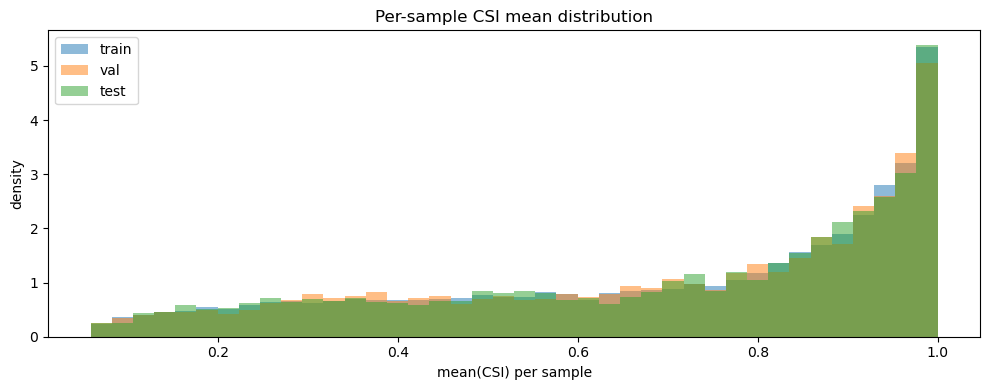

In [7]:
report = summarize_split_csi_mean(
    y,
    idx_train=idx_train,
    idx_val=idx_val,
    idx_test=idx_test,
    bins=40,
    plot=True
)

In [8]:
channel_min = np.nanmin(X_train, axis=(0, 2, 3))  
channel_max = np.nanmax(X_train, axis=(0, 2, 3))

# optional: protect against zero range channels
channel_range = channel_max - channel_min
channel_range[channel_range < 1e-6] = 1e-6

np.savez(
    "data/norm/minmax_stratified.npz",
    channel_min=channel_min,
    channel_max=channel_max,
)

In [9]:
train_dataset = BandsCamsDataset(X_train, y_train, channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)
val_dataset   = BandsCamsDataset(X_val,   y_val,   channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)
test_dataset  = BandsCamsDataset(X_test,  y_test,  channel_min, channel_max,
                                 elev_ch_idx=-2, land_ch_idx=-1)
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
    num_workers=8, pin_memory=True,
    persistent_workers=True, prefetch_factor=2)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

## 3. Model Architecture and Training

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
# torch.cuda.set_device(0)
model = GUM(feature_size=64, K=2, gate_temp=0.7).to(device)
print(gate_stats(model, val_loader, device, K=2))

{'hard_usage': array([0.975757  , 0.02424297], dtype=float32), 'mean_max_weight': 0.6407258152961731, 'mean_entropy': 0.6444167584180832}


In [ ]:
best_ckpt = train_gum(
    model, train_loader, val_loader, device,
    total_epochs=50,
    lr=1e-4, max_lr=3e-4,
    weight_decay=1e-3,
    lam_bal=0.001,
    full_val_every=5,
    val_batches_quick=30,
    ckpt_name="best_gum_tempnorm_test.pt"
)

/Users/tjdu/Desktop/NOCITIS/src/nocitis/gum/train.py:192: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/opt/anaconda3/envs/nocitis/lib/python3.10/site-packages/torch/cuda/amp/grad_scaler.py:31: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  super().__init__(
/opt/anaconda3/envs/nocitis/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1102: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


## 4. Evaluation and Performance Metrics

In [11]:
# --- load best model for evaluation ---
PATH = "model_checkpoint/best_gum_temp_norm.pt"
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
sd = torch.load(PATH, map_location=device)["model"]
if any(k.startswith("_orig_mod.") for k in sd.keys()):
    sd = {k.replace("_orig_mod.", ""): v for k, v in sd.items()}
model.load_state_dict(sd)

<All keys matched successfully>

In [12]:
df_results = evaluate_table_metrics(
    model, 
    test_loader, 
    device, 
    cs_ghi_full=c1, 
    time_mins_full=t, 
    idx_eval=idx_test
)
display(df_results)

RMSE  rRMSE (%)        MAE       MBE        R2
Target Category / Period                                                     
CSI    Clear sky           0.059061   6.387817   0.029487  0.002686  0.800040
       Cloudy sky          0.099080  43.712528   0.068877  0.008878  0.602301
       Morning (5-8)       0.123500  17.306859   0.075014 -0.003908  0.835479
       Day (8-16)          0.080130  11.493846   0.048817  0.002476  0.935343
       Evening (16-19)     0.099773  14.310417   0.061702  0.001370  0.896897
       Overall (All sky)   0.087852  12.576644   0.053048  0.001769  0.921517
GHI    Clear sky          36.570269   6.626541  16.935054  1.740759  0.978841
       Cloudy sky         55.359791  43.333653  36.733180  6.619607  0.745510
       Morning (5-8)      28.709121  17.419446  16.831720  0.765948  0.905395
       Day (8-16)         56.601594  11.699861  33.234600  2.183126  0.954948
       Evening (16-19)    25.106429  13.088065  15.345404  1.506327  0.963930
       Overall (All sky)  50.948348  12.404319  29.019516  1.957490  0.964961

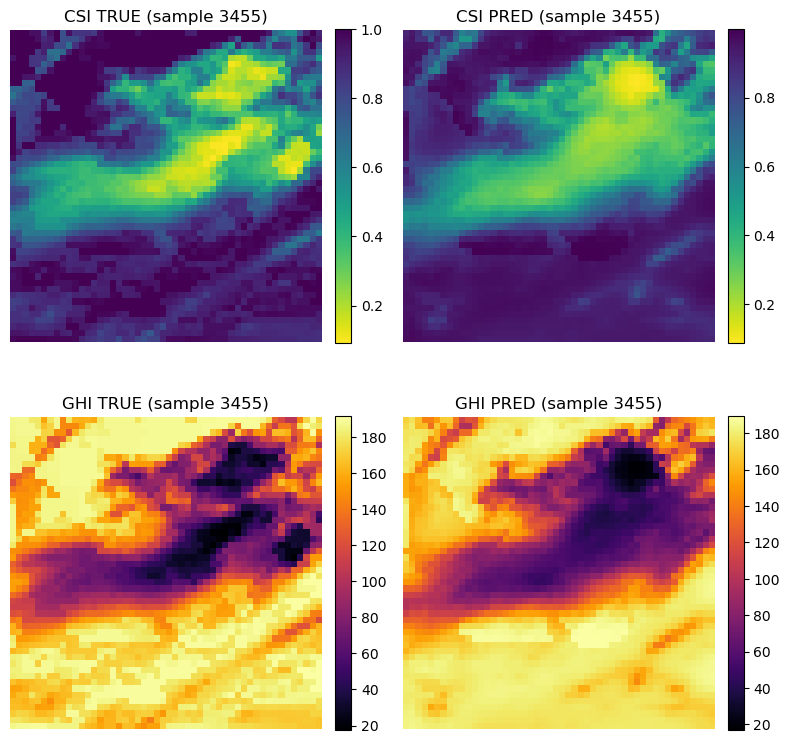

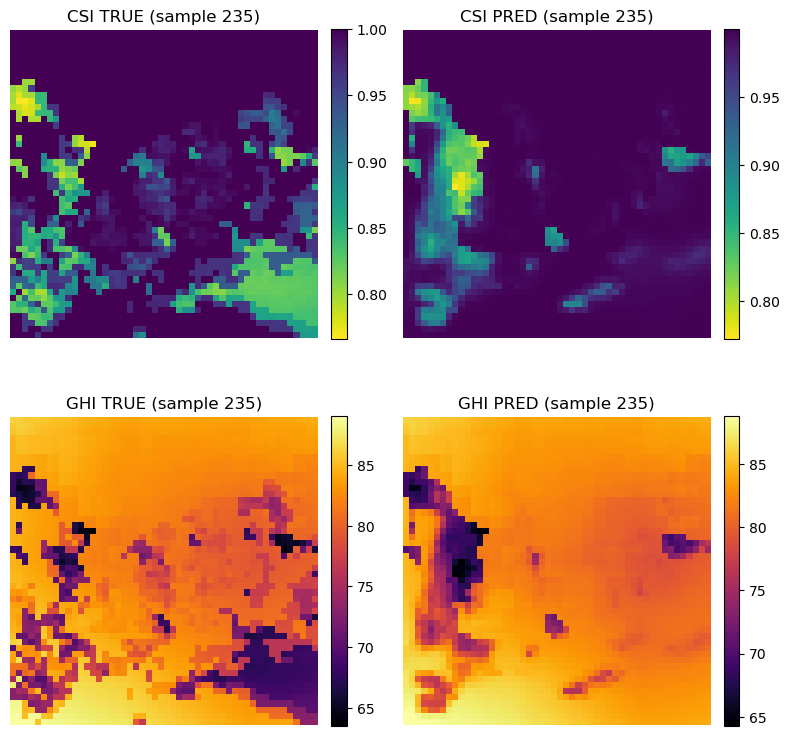

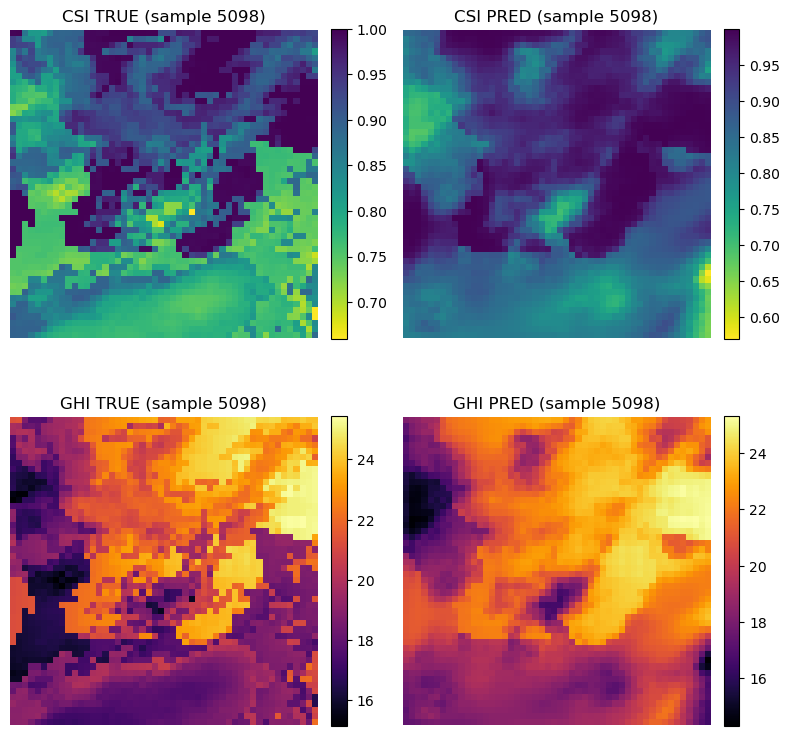

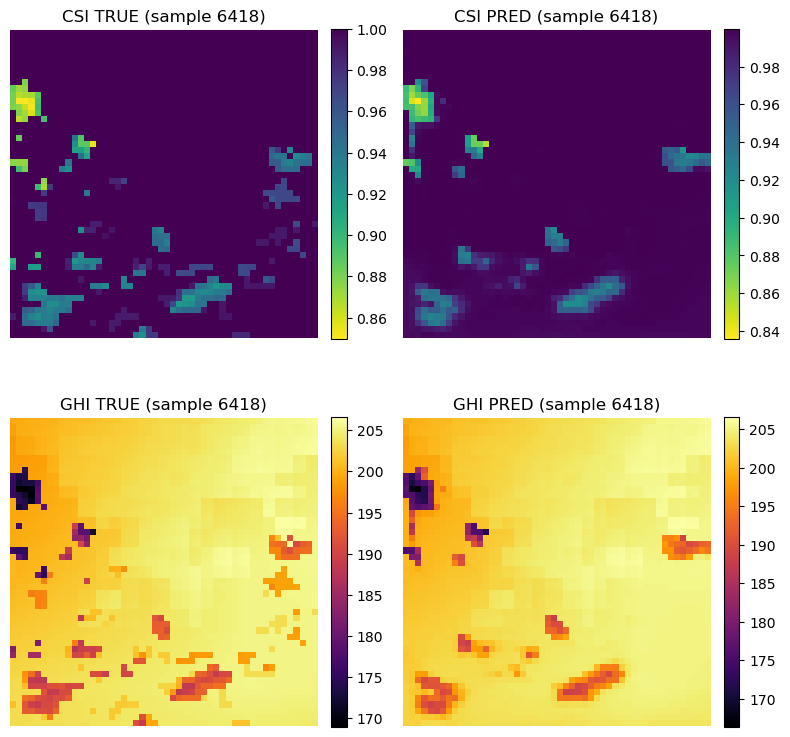

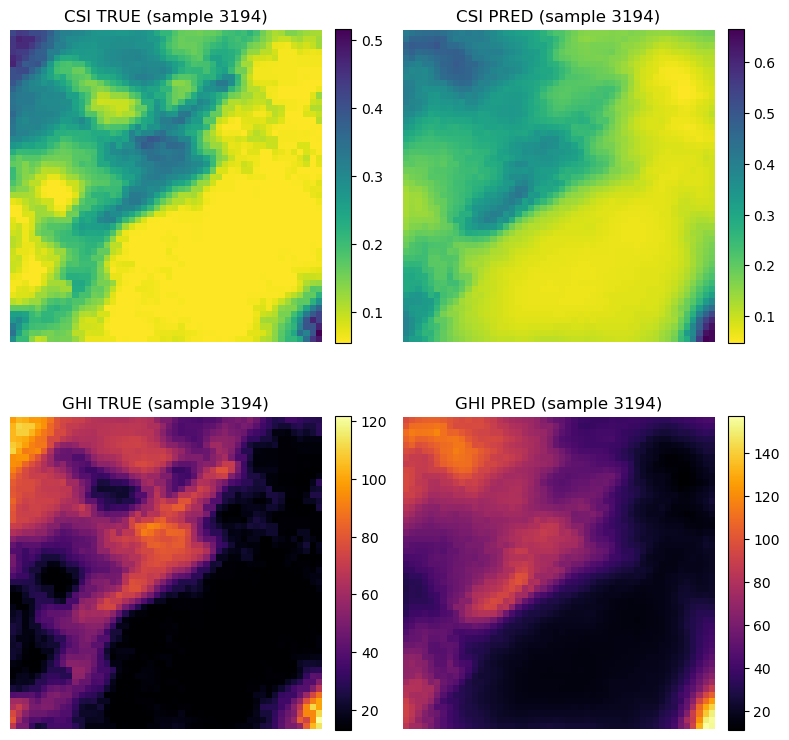

In [14]:
ghi_cs_all = cams_data[:, 1, :, :] 
ghi_cs_test = ghi_cs_all[idx_test]
ghi_cs_test = ghi_cs_test[:, None, :, :]   # (T_test,H,W)
plot_full_images_from_loader(
    model,
    test_loader,
    device,
    ghi_cs_test,
    n_samples=5,
    seed=1
)